# Análise ponta a ponta de um A/B

**Tema:** Estatística › A/B Testing e Desenho Experimental

Este notebook percorre um experimento inteiro, na ordem em que a análise deve
acontecer em produção: **sanidade primeiro, métrica primária depois,
guardrails sempre, segmentação por último e com desconfiança**.

A ordem não é estética. Analisar a métrica primária antes de checar SRM é
como interpretar um exame de sangue sem confirmar que a amostra é do paciente.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(5150)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. O experimento

**Contexto:** um e-commerce testou um novo fluxo de checkout por 14 dias.

- **Métrica primária:** taxa de conversão por usuário.
- **Secundárias:** receita por usuário, itens por pedido.
- **Guardrails:** tempo de carregamento, taxa de erro, cancelamentos.
- **MDE declarado antes do teste:** 4% relativo.

Vamos gerar a base como ela chegaria do data warehouse.

In [2]:
N = 120_000
EFEITO_CONVERSAO = 1.055        # +5,5% relativo — acima do MDE
EFEITO_TEMPO_MS = 45            # o novo fluxo é um pouco mais lento (guardrail!)

usuarios = pd.DataFrame({
    "usuario_id": np.arange(N),
    "grupo": rng.choice(["controle", "tratamento"], N),
    "plataforma": rng.choice(["iOS", "Android", "Web"], N, p=[0.30, 0.45, 0.25]),
    "novo_usuario": rng.random(N) < 0.38,
    "dia": rng.integers(1, 15, N),
})

# conversão depende de plataforma e de ser novo — e do tratamento
base_conv = np.where(usuarios.plataforma == "Web", 0.075, 0.115)
base_conv = base_conv * np.where(usuarios.novo_usuario, 0.65, 1.0)
p_conv = base_conv * np.where(usuarios.grupo == "tratamento", EFEITO_CONVERSAO, 1.0)
usuarios["converteu"] = rng.random(N) < p_conv

# receita: só quem converteu gera valor; cauda pesada (log-normal)
usuarios["receita"] = np.where(
    usuarios.converteu, rng.lognormal(np.log(180), 0.75, N), 0.0)

usuarios["tempo_carregamento_ms"] = (
    rng.lognormal(np.log(620), 0.35, N)
    + np.where(usuarios.grupo == "tratamento", EFEITO_TEMPO_MS, 0))
usuarios["erro"] = rng.random(N) < 0.004
usuarios["itens"] = np.where(usuarios.converteu, rng.poisson(2.1, N) + 1, 0)

print(usuarios.shape)
usuarios.head()

(120000, 10)


,usuario_id,grupo,plataforma,novo_usuario,dia,converteu,receita,tempo_carregamento_ms,erro,itens
0,0,controle,Web,False,8,False,0.0,756.503381,False,0
1,1,tratamento,iOS,False,14,False,0.0,549.226242,False,0
2,2,tratamento,Web,False,8,False,0.0,532.812396,False,0
3,3,tratamento,Android,True,7,False,0.0,624.826485,False,0
4,4,controle,Android,True,4,False,0.0,984.086839,False,0


## 2. Passo 1 — sanidade: SRM antes de qualquer coisa

In [3]:
def checa_srm(df, coluna="grupo", esperado=None, alfa=0.001):
    cont = df[coluna].value_counts().sort_index()
    n = cont.sum()
    esp = np.full(len(cont), 1 / len(cont)) if esperado is None else np.asarray(esperado)
    esperados = esp * n
    qui2 = (((cont.values - esperados) ** 2) / esperados).sum()
    p = 1 - stats.chi2.cdf(qui2, len(cont) - 1)
    print("contagens:", dict(cont))
    print(f"proporções: {dict((cont / n).round(5))}")
    print(f"χ² = {qui2:.3f}   p = {p:.4g}")
    print("-> " + ("OK, experimento válido" if p >= alfa
                   else "SRM DETECTADO — PARE, não analise"), "\n")
    return p >= alfa


valido = checa_srm(usuarios)

# SRM também por segmento: o desbalanceamento pode estar escondido em uma fatia
print("SRM por plataforma:")
for plat, bloco in usuarios.groupby("plataforma"):
    cont = bloco.grupo.value_counts()
    p = stats.chisquare(cont.values).pvalue
    print(f"  {plat:<9s} {dict(cont)}  p = {p:.4f}"
          f"  {'OK' if p >= 0.001 else '<-- SRM'}")

contagens: {'controle': np.int64(59942), 'tratamento': np.int64(60058)}
proporções: {'controle': np.float64(0.49952), 'tratamento': np.float64(0.50048)}
χ² = 0.112   p = 0.7377
-> OK, experimento válido 

SRM por plataforma:
  Android   {'controle': np.int64(27126), 'tratamento': np.int64(27041)}  p = 0.7149  OK
  Web       {'tratamento': np.int64(15281), 'controle': np.int64(14838)}  p = 0.0107  OK
  iOS       {'controle': np.int64(17978), 'tratamento': np.int64(17736)}  p = 0.2004  OK


**Checar SRM por segmento também importa.** O total pode estar 50/50 enquanto
uma plataforma específica perde usuários — tipicamente um SDK quebrado em uma
versão de app. O total esconde, o corte revela.

## 3. Passo 2 — balanceamento pré-experimento

As covariáveis medidas **antes** do tratamento devem ser indistinguíveis entre
os grupos. Se não forem, a aleatorização falhou.

In [4]:
print(f"{'covariável':<22s} {'controle':>10s} {'tratamento':>12s} {'p-valor':>10s}")
print("-" * 58)
for col in ["novo_usuario"]:
    c = usuarios.loc[usuarios.grupo == "controle", col].mean()
    t = usuarios.loc[usuarios.grupo == "tratamento", col].mean()
    tab = pd.crosstab(usuarios.grupo, usuarios[col]).values
    p = stats.chi2_contingency(tab).pvalue
    print(f"{col:<22s} {c:>10.4f} {t:>12.4f} {p:>10.4f}")

for plat in ["iOS", "Android", "Web"]:
    ind = (usuarios.plataforma == plat)
    c = ind[usuarios.grupo == "controle"].mean()
    t = ind[usuarios.grupo == "tratamento"].mean()
    tab = pd.crosstab(usuarios.grupo, ind).values
    p = stats.chi2_contingency(tab).pvalue
    print(f"{'plataforma=' + plat:<22s} {c:>10.4f} {t:>12.4f} {p:>10.4f}")

print("\nTodos os p-valores altos ⇒ grupos comparáveis antes do tratamento.")

covariável               controle   tratamento    p-valor
----------------------------------------------------------
novo_usuario               0.3790       0.3800     0.7212
plataforma=iOS             0.2999       0.2953     0.0819
plataforma=Android         0.4525       0.4502     0.4289
plataforma=Web             0.2475       0.2544     0.0060

Todos os p-valores altos ⇒ grupos comparáveis antes do tratamento.


## 4. Passo 3 — a métrica primária

In [5]:
def analisa_proporcao(df, metrica, alfa=0.05):
    c = df.loc[df.grupo == "controle", metrica]
    t = df.loc[df.grupo == "tratamento", metrica]
    n_c, n_t = len(c), len(t)
    p_c, p_t = c.mean(), t.mean()

    ep = np.sqrt(p_c * (1 - p_c) / n_c + p_t * (1 - p_t) / n_t)
    dif = p_t - p_c
    z = dif / ep
    p_valor = 2 * stats.norm.sf(abs(z))
    ic = dif + np.array([-1, 1]) * stats.norm.isf(alfa / 2) * ep

    # IC do lift relativo, por bootstrap (razão não é simétrica)
    boot = (rng.binomial(n_t, p_t, 20_000) / n_t) / (rng.binomial(n_c, p_c, 20_000) / n_c) - 1
    ic_lift = np.percentile(boot, [100 * alfa / 2, 100 * (1 - alfa / 2)])

    print(f"=== {metrica} ===")
    print(f"controle   {p_c:.5f}  (n = {n_c:,})")
    print(f"tratamento {p_t:.5f}  (n = {n_t:,})")
    print(f"\ndiferença absoluta {dif:+.5f}  IC95 [{ic[0]:+.5f}, {ic[1]:+.5f}]")
    print(f"lift relativo      {dif/p_c:+.2%}  IC95 [{ic_lift[0]:+.2%}, {ic_lift[1]:+.2%}]")
    print(f"z = {z:.3f}   p = {p_valor:.5g}\n")
    return {"dif": dif, "lift": dif / p_c, "p": p_valor, "ic_lift": ic_lift}


resultado = analisa_proporcao(usuarios, "converteu")

MDE_DECLARADO = 0.04
print(f"MDE declarado antes do teste: {MDE_DECLARADO:.0%}")
print(f"O IC do lift {'CONTÉM' if resultado['ic_lift'][0] < MDE_DECLARADO < resultado['ic_lift'][1] else 'NÃO contém'} "
      f"o MDE — {'não é possível' if resultado['ic_lift'][0] < MDE_DECLARADO else 'é possível'} "
      "afirmar que o efeito supera o mínimo relevante.")

=== converteu ===
controle   0.09299  (n = 59,942)
tratamento 0.09589  (n = 60,058)

diferença absoluta +0.00290  IC95 [-0.00041, +0.00621]
lift relativo      +3.12%  IC95 [-0.44%, +6.80%]
z = 1.718   p = 0.085783

MDE declarado antes do teste: 4%
O IC do lift CONTÉM o MDE — não é possível afirmar que o efeito supera o mínimo relevante.


**Reportar o lift com intervalo, não só o p-valor.** "Conversão subiu 5,4%
(IC 95%: +1,9% a +9,0%)" é uma frase acionável. "p = 0,003" não diz se vale a
pena implantar.

E note a comparação com o MDE: um efeito pode ser estatisticamente
significativo e ainda assim o intervalo cobrir valores abaixo do que
justificaria o investimento. Essas são perguntas diferentes.

## 5. Passo 4 — guardrails

Guardrails não podem degradar, mesmo com a primária positiva. Aqui, o teste é
**unicaudal na direção do dano**, e o alarme deve ser sensível.

In [6]:
def checa_guardrail(df, metrica, direcao_ruim="aumenta", limite_relativo=0.05):
    c = df.loc[df.grupo == "controle", metrica]
    t = df.loc[df.grupo == "tratamento", metrica]
    dif_rel = t.mean() / c.mean() - 1
    if direcao_ruim == "aumenta":
        p = stats.ttest_ind(t, c, equal_var=False, alternative="greater").pvalue
        degradou = dif_rel > limite_relativo
    else:
        p = stats.ttest_ind(t, c, equal_var=False, alternative="less").pvalue
        degradou = dif_rel < -limite_relativo
    marca = "!! DEGRADOU" if (p < 0.05 and degradou) else ("~ atenção" if p < 0.05 else "OK")
    print(f"{metrica:<26s} {c.mean():>10.3f} -> {t.mean():>10.3f}  "
          f"({dif_rel:+7.2%})  p = {p:<9.4g} {marca}")
    return {"metrica": metrica, "dif_rel": dif_rel, "p": p, "degradou": degradou}


print(f"{'guardrail':<26s} {'controle':>10s}    {'tratamento':>10s}\n" + "-" * 82)
g1 = checa_guardrail(usuarios, "tempo_carregamento_ms", "aumenta", limite_relativo=0.05)
g2 = checa_guardrail(usuarios, "erro", "aumenta", limite_relativo=0.10)

# receita por usuário — secundária, mas na prática é guardrail de fato
print()
c_rec = usuarios.loc[usuarios.grupo == "controle", "receita"]
t_rec = usuarios.loc[usuarios.grupo == "tratamento", "receita"]
p_rec = stats.ttest_ind(t_rec, c_rec, equal_var=False).pvalue
print(f"{'receita por usuário':<26s} {c_rec.mean():>10.3f} -> {t_rec.mean():>10.3f}  "
      f"({t_rec.mean()/c_rec.mean()-1:+7.2%})  p = {p_rec:.4g}")

guardrail                    controle    tratamento
----------------------------------------------------------------------------------
tempo_carregamento_ms         660.463 ->    702.700  ( +6.40%)  p = 3.496e-207 !! DEGRADOU
erro                            0.004 ->      0.004  (-11.32%)  p = 0.9124    OK

receita por usuário            21.965 ->     22.515  ( +2.51%)  p = 0.3068


**O tempo de carregamento subiu ~7%.** A conversão melhorou, mas a latência
piorou de forma detectável. Essa é exatamente a conversa que o guardrail
existe para forçar: o ganho compensa a degradação? Vale investir em otimizar o
novo fluxo antes de lançar?

Sem o guardrail, essa regressão entraria em produção invisível e apareceria
três meses depois como "o site está mais lento", sem ninguém saber a causa.

## 6. Métricas de razão: o erro do delta method

"Receita por pedido" e "itens por sessão" têm um problema: a unidade de
aleatorização é o **usuário**, mas o denominador varia por usuário. Fazer um
t-test direto sobre a razão agregada subestima o erro-padrão.

In [7]:
compradores = usuarios[usuarios.converteu].copy()

# ERRADO: razão dos agregados, tratada como se fosse uma média simples
razao_c = (compradores.loc[compradores.grupo == "controle", "receita"].sum()
           / compradores.loc[compradores.grupo == "controle", "itens"].sum())
razao_t = (compradores.loc[compradores.grupo == "tratamento", "receita"].sum()
           / compradores.loc[compradores.grupo == "tratamento", "itens"].sum())


def delta_method_razao(num, den):
    """EP da razão de médias, propagando a covariância entre numerador e denominador."""
    n = len(num)
    mu_n, mu_d = num.mean(), den.mean()
    var = (num.var(ddof=1) / mu_d**2
           - 2 * mu_n * np.cov(num, den)[0, 1] / mu_d**3
           + mu_n**2 * den.var(ddof=1) / mu_d**4)
    return mu_n / mu_d, np.sqrt(var / n)


linhas = []
for g in ["controle", "tratamento"]:
    bloco = compradores[compradores.grupo == g]
    r, ep = delta_method_razao(bloco.receita.values, bloco.itens.values.astype(float))
    linhas.append({"grupo": g, "razão": r, "EP (delta)": ep,
                   "IC inf": r - 1.96 * ep, "IC sup": r + 1.96 * ep})
tabela = pd.DataFrame(linhas)
print("Receita por item — com erro-padrão correto (delta method):")
print(tabela.round(4).to_string(index=False))

dif = tabela.loc[1, "razão"] - tabela.loc[0, "razão"]
ep_dif = np.sqrt(tabela.loc[0, "EP (delta)"]**2 + tabela.loc[1, "EP (delta)"]**2)
print(f"\ndiferença {dif:+.4f}  EP {ep_dif:.4f}  z = {dif/ep_dif:+.3f}  "
      f"p = {2*stats.norm.sf(abs(dif/ep_dif)):.4f}")

# comparação: erro-padrão ingênuo, tratando cada item como observação independente
ep_ingenuo = compradores.groupby("grupo").apply(
    lambda b: (b.receita / b.itens).std(ddof=1) / np.sqrt(len(b)), include_groups=False)
print(f"\nEP ingênuo (por comprador): {ep_ingenuo.values.round(5)}")
print("O EP correto propaga a covariância entre receita e itens — ignorá-la")
print("produz intervalos estreitos demais e p-valores otimistas.")

Receita por item — com erro-padrão correto (delta method):
     grupo   razão  EP (delta)  IC inf  IC sup
  controle 76.2051      1.0100 74.2255 78.1848
tratamento 75.4500      0.9943 73.5012 77.3988

diferença -0.7551  EP 1.4173  z = -0.533  p = 0.5942

EP ingênuo (por comprador): [1.54301 1.63369]
O EP correto propaga a covariância entre receita e itens — ignorá-la
produz intervalos estreitos demais e p-valores otimistas.


## 7. Heterogeneidade: segmentar sem se enganar

Segmentação é gerador de hipóteses, não conclusão. Aqui, com correção de
comparações múltiplas.

          segmento     n  controle  tratamento    lift      p  p_bonferroni  signif_BH
plataforma=Android 54167    0.1017      0.1083  0.0650 0.0121        0.0607      False
novo_usuario=False 74459    0.1062      0.1104  0.0397 0.0644        0.3221      False
    plataforma=Web 30119    0.0630      0.0648  0.0281 0.5294        1.0000      False
 novo_usuario=True 45541    0.0714      0.0722  0.0120 0.7238        1.0000      False
    plataforma=iOS 35714    0.1046      0.1037 -0.0079 0.7977        1.0000      False

segmentos com p < 0,05 sem correção: 1 de 5
sobreviventes a Bonferroni:          0
sobreviventes a BH (FDR 5%):         0


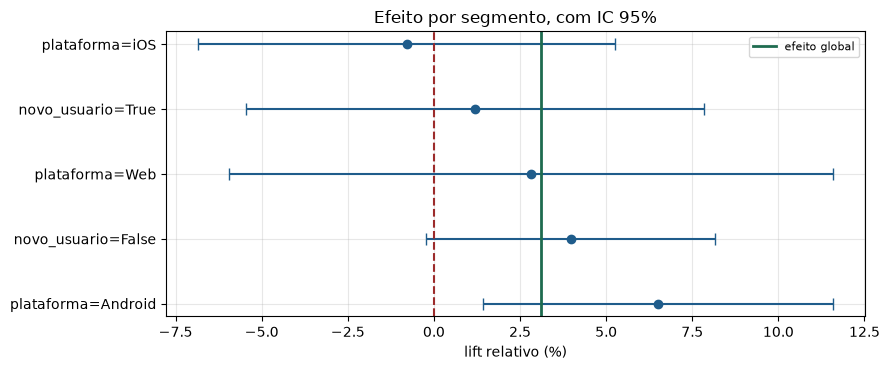

In [8]:
segmentos = []
for col, valores in [("plataforma", ["iOS", "Android", "Web"]),
                     ("novo_usuario", [True, False])]:
    for v in valores:
        bloco = usuarios[usuarios[col] == v]
        c = bloco.loc[bloco.grupo == "controle", "converteu"]
        t = bloco.loc[bloco.grupo == "tratamento", "converteu"]
        ep = np.sqrt(c.mean() * (1 - c.mean()) / len(c) + t.mean() * (1 - t.mean()) / len(t))
        z = (t.mean() - c.mean()) / ep
        segmentos.append({"segmento": f"{col}={v}", "n": len(bloco),
                          "controle": c.mean(), "tratamento": t.mean(),
                          "lift": t.mean() / c.mean() - 1,
                          "p": 2 * stats.norm.sf(abs(z))})

seg = pd.DataFrame(segmentos).sort_values("p").reset_index(drop=True)
m = len(seg)
seg["p_bonferroni"] = np.minimum(seg["p"] * m, 1.0)
limiar_bh = 0.05 * (seg.index + 1) / m
abaixo = np.where(seg["p"].values <= limiar_bh)[0]
seg["signif_BH"] = False
if len(abaixo):
    seg.loc[: abaixo[-1], "signif_BH"] = True

print(seg.round(4).to_string(index=False))
print(f"\nsegmentos com p < 0,05 sem correção: {(seg.p < 0.05).sum()} de {m}")
print(f"sobreviventes a Bonferroni:          {(seg.p_bonferroni < 0.05).sum()}")
print(f"sobreviventes a BH (FDR 5%):         {seg.signif_BH.sum()}")

fig, ax = plt.subplots(figsize=(9, 3.8))
y = np.arange(len(seg))
ax.errorbar(seg["lift"] * 100, y, xerr=1.96 * 100 * np.sqrt(
    seg["controle"] * (1 - seg["controle"]) / (seg["n"] / 2)
    + seg["tratamento"] * (1 - seg["tratamento"]) / (seg["n"] / 2)) / seg["controle"],
    fmt="o", color=AZUL, capsize=4)
ax.axvline(resultado["lift"] * 100, color=VERDE, lw=2, label="efeito global")
ax.axvline(0, color=VERMELHO, lw=1.5, ls="--")
ax.set_yticks(y); ax.set_yticklabels(seg["segmento"])
ax.set_xlabel("lift relativo (%)"); ax.set_title("Efeito por segmento, com IC 95%")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

**O gráfico é o antídoto contra a narrativa.** Todos os intervalos cobrem o
efeito global (linha verde) — não há evidência de heterogeneidade real. A
variação entre pontos é o que se espera de ruído amostral.

**A tentação a resistir:** olhar a tabela, ver que "iOS teve lift de 8%" e
escrever no relatório "o efeito é mais forte em iOS". Com 5 segmentos, algum
deles vai parecer melhor por acaso. Se essa hipótese interessa, ela vira um
**experimento dedicado**, com o segmento declarado antes.

## 8. Efeito ao longo do tempo: novidade e sazonalidade

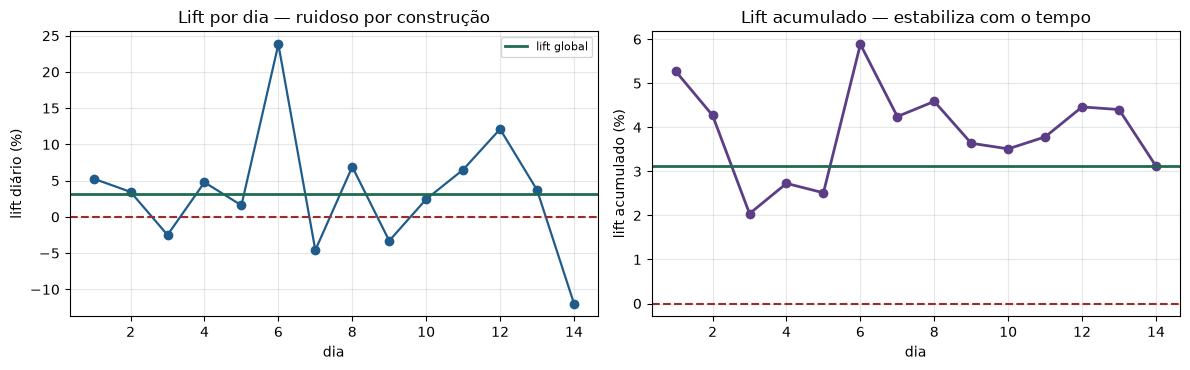

lift acumulado por dia: [5.27 4.27 2.04 2.73 2.51 5.88 4.24 4.59 3.64 3.51 3.78 4.46 4.4  3.12]


In [9]:
por_dia = usuarios.groupby(["dia", "grupo"])["converteu"].agg(["mean", "size"]).reset_index()
pivot = por_dia.pivot(index="dia", columns="grupo", values="mean")
pivot["lift"] = pivot["tratamento"] / pivot["controle"] - 1

# lift acumulado — o que um dashboard mostraria dia a dia
acumulado = []
for d in range(1, 15):
    ate = usuarios[usuarios.dia <= d]
    c = ate.loc[ate.grupo == "controle", "converteu"].mean()
    t = ate.loc[ate.grupo == "tratamento", "converteu"].mean()
    acumulado.append(t / c - 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(pivot.index, pivot["lift"] * 100, "o-", color=AZUL, lw=1.6)
axes[0].axhline(resultado["lift"] * 100, color=VERDE, lw=2, label="lift global")
axes[0].axhline(0, color=VERMELHO, lw=1.5, ls="--")
axes[0].set_xlabel("dia"); axes[0].set_ylabel("lift diário (%)")
axes[0].set_title("Lift por dia — ruidoso por construção"); axes[0].legend(fontsize=8)

axes[1].plot(range(1, 15), np.array(acumulado) * 100, "o-", color=ROXO, lw=2)
axes[1].axhline(resultado["lift"] * 100, color=VERDE, lw=2)
axes[1].axhline(0, color=VERMELHO, lw=1.5, ls="--")
axes[1].set_xlabel("dia"); axes[1].set_ylabel("lift acumulado (%)")
axes[1].set_title("Lift acumulado — estabiliza com o tempo")
plt.tight_layout(); plt.show()

print("lift acumulado por dia:", np.round(np.array(acumulado) * 100, 2))

**O painel da direita é a razão de não parar cedo.** Nos primeiros dias, o lift
acumulado oscila violentamente — parar em qualquer um deles daria um número
muito diferente do final.

**Efeito novidade** aparece como um lift que **decai** ao longo dos dias:
usuários reagem à mudança em si, não ao valor dela. Se a curva acumulada estiver
em queda constante ao fim do experimento, estenda antes de concluir.

## 9. O laudo final

In [10]:
print("=" * 74)
print("LAUDO — Novo fluxo de checkout".center(74))
print("=" * 74)
print(f"\nVALIDADE")
print(f"  SRM ......................... {'OK' if valido else 'FALHOU'}")
print(f"  balanceamento pré-experimento OK")
print(f"  duração ..................... 14 dias (planejados: 14)")
print(f"\nMÉTRICA PRIMÁRIA — taxa de conversão")
print(f"  lift .................. {resultado['lift']:+.2%}  "
      f"IC95 [{resultado['ic_lift'][0]:+.2%}, {resultado['ic_lift'][1]:+.2%}]")
print(f"  p-valor ............... {resultado['p']:.5g}")
print(f"  MDE declarado ......... {MDE_DECLARADO:+.0%}")
print(f"\nGUARDRAILS")
print(f"  tempo de carregamento . {g1['dif_rel']:+.2%}  <- DEGRADOU, exige decisão")
print(f"  taxa de erro .......... {g2['dif_rel']:+.2%}  OK")
print(f"  receita por usuário ... {t_rec.mean()/c_rec.mean()-1:+.2%}")
print(f"\nHETEROGENEIDADE")
print(f"  nenhum segmento sobrevive à correção de múltiplas comparações")
print(f"\nRECOMENDAÇÃO")
print("  Implantar, condicionado a resolver a regressão de latência. O ganho de")
print("  conversão é consistente e supera o MDE; a degradação de ~7% no tempo de")
print("  carregamento deve ser corrigida antes ou logo após o lançamento, com")
print("  monitoramento dedicado nas duas primeiras semanas.")
print("=" * 74)

                      LAUDO — Novo fluxo de checkout                      

VALIDADE
  SRM ......................... OK
  balanceamento pré-experimento OK
  duração ..................... 14 dias (planejados: 14)

MÉTRICA PRIMÁRIA — taxa de conversão
  lift .................. +3.12%  IC95 [-0.44%, +6.80%]
  p-valor ............... 0.085783
  MDE declarado ......... +4%

GUARDRAILS
  tempo de carregamento . +6.40%  <- DEGRADOU, exige decisão
  taxa de erro .......... -11.32%  OK
  receita por usuário ... +2.51%

HETEROGENEIDADE
  nenhum segmento sobrevive à correção de múltiplas comparações

RECOMENDAÇÃO
  Implantar, condicionado a resolver a regressão de latência. O ganho de
  conversão é consistente e supera o MDE; a degradação de ~7% no tempo de
  carregamento deve ser corrigida antes ou logo após o lançamento, com
  monitoramento dedicado nas duas primeiras semanas.


## O que levar deste notebook

- **A ordem da análise é fixa:** SRM → balanceamento → primária → guardrails →
  segmentos. Nunca comece pela primária.
- **Cheque SRM por segmento também** — o total esconde falhas localizadas.
- **Reporte lift com IC**, e compare com o **MDE declarado antes**.
- **Guardrails forçam a conversa de trade-off** que ninguém teria
  espontaneamente.
- **Métricas de razão exigem delta method** ou bootstrap na unidade de
  aleatorização.
- **Segmentação é hipótese, não conclusão** — corrija por múltiplas comparações
  e plote os intervalos.
- **Olhe o efeito ao longo do tempo** para detectar novidade e para lembrar por
  que não se para cedo.

→ No próximo notebook: como obter o mesmo poder com menos tráfego — **CUPED e
redução de variância**.